## Get Deflock location by using OpenStreetMap 
- Deflock: https://deflock.org/map (Used to help ground truth the LPR.)
- OpoenStreetMap overpass turbo: https://overpass-turbo.eu/# (Used to get the LPR location.)

#### Identify the location and area
1. In this part, identify the area that we want to focus on for LPR.
2. Go to OSM overpass turbo https://overpass-turbo.eu/# and change the geocodeArea.<br>
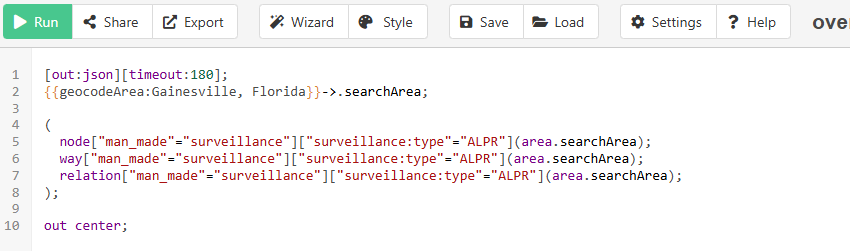
3. Run the script and Export as a raw OSM data file.

#### Covert json file to csv file
Below is the script to convert json file to csv file.
1. Make sure to change the json path.
2. Locate the folder that you want to store the csv file.

In [ ]:
import json
import pandas as pd

# Path to your Overpass export
json_path = "Your_Json_Path"   # change if needed

# Load JSON
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []

for element in data["elements"]:
    if element["type"] == "node":
        row = {
            "osm_id": element.get("id"),
            "latitude": element.get("lat"),
            "longitude": element.get("lon")
        }
        
        # Flatten tags
        tags = element.get("tags", {})
        for key, value in tags.items():
            clean_key = key.replace(":", "_")  # ArcGIS-friendly field names
            row[clean_key] = value
        
        rows.append(row)

# Create DataFrame
df = pd.DataFrame(rows)

# Sort by ID (optional)
df = df.sort_values("osm_id")

# Display first few rows
print(df.head())

# Save to CSV (for ArcGIS / Excel)
df.to_csv("Your_Path", index=False) # change if needed

print("Attribute table saved as Your_file.csv")

        osm_id   latitude  longitude camera_mount camera_type direction  \
0  12351591956  29.628649 -82.388102         pole       fixed        45   
1  12351621572  29.622957 -82.377008         pole       fixed       285   
2  12351623450  29.658882 -82.409050         pole       fixed       145   
3  12351626461  29.621436 -82.385412         pole       fixed        80   
4  12351631929  29.624296 -82.380818          NaN       fixed       345   

       man_made  manufacturer manufacturer_wikidata surveillance  \
0  surveillance  Flock Safety            Q108485435      traffic   
1  surveillance           NaN                   NaN      traffic   
2  surveillance  Flock Safety            Q108485435      traffic   
3  surveillance  Flock Safety            Q108485435      traffic   
4  surveillance  Flock Safety            Q108485435      traffic   

  surveillance_type surveillance_zone operator operator_wikidata  
0              ALPR           traffic      NaN               NaN  
1     

In [ ]:
# Here is the link for overpass turbo and the script just in case 
'''
https://overpass-turbo.eu/#
[out:json][timeout:180];
{{geocodeArea:Scottsdale, Arizona}}->.searchArea;

(
  node["man_made"="surveillance"]["surveillance:type"="ALPR"]
      ["manufacturer"~"flock",i](area.searchArea);
  way["man_made"="surveillance"]["surveillance:type"="ALPR"]
      ["manufacturer"~"flock",i](area.searchArea);
  relation["man_made"="surveillance"]["surveillance:type"="ALPR"]
      ["manufacturer"~"flock",i](area.searchArea);
);

out center;

'''
